# Pollution, Air Quality & Mortality: Data Analysis

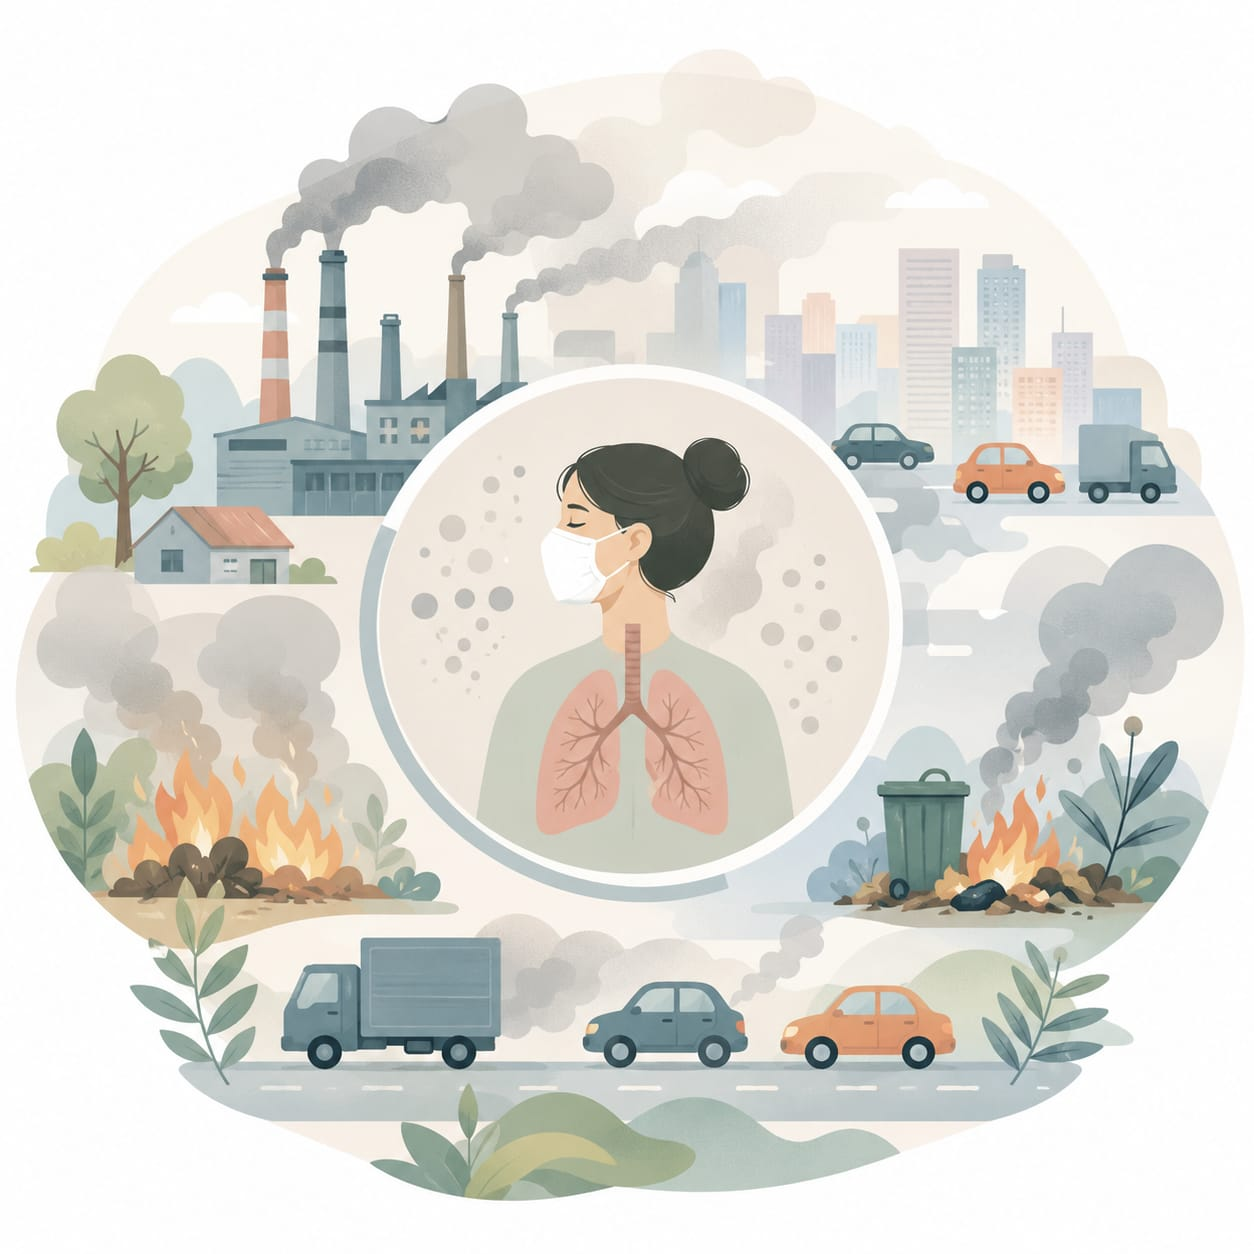

## Section 1: Data Processing and Summarizing

### 1.1 Data Preprocessing & Merging

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Load datasets
ozone = pd.read_stata("data-task-2025-ozone.dta")
pm25 = pd.read_stata("data-task-2025-pm.dta")

print("Ozone dataset dimensions:", ozone.shape)
print("PM2.5 dataset dimensions:", pm25.shape)

Ozone dataset dimensions: (33877, 10)
PM2.5 dataset dimensions: (33877, 5)


In [ ]:
display(ozone.head())
display(pm25.head())

,county_code,county_name,date,siteid,cbsacode,cbsaname,aqi,ozone_source,ozone_value,mortality
0,1,Alameda,01/01/2024,60010009,41860.0,"San Francisco-Oakland-Hayward, CA",37.0,AQS,0.024,NaN
1,1,Alameda,01/01/2024,60010011,41860.0,"San Francisco-Oakland-Hayward, CA",38.0,AQS,0.022,NaN
2,1,Alameda,01/01/2024,60010007,41860.0,"San Francisco-Oakland-Hayward, CA",36.0,AQS,0.031,NaN
3,1,Alameda,01/02/2024,60010007,41860.0,"San Francisco-Oakland-Hayward, CA",20.0,AQS,0.037,NaN
4,1,Alameda,01/02/2024,60010011,41860.0,"San Francisco-Oakland-Hayward, CA",24.0,AQS,0.034,NaN


,county_code,pm25_source,siteid,pm25_value,date
0,001,AQS,60010007,6.400000,2024-01-01
1,001,AQS,60010009,6.600000,2024-01-01
2,001,AQS,60010011,6.900000,2024-01-01
3,007,AQS,60070008,18.799999,2024-01-01
4,007,AQS,60072003,3.800000,2024-01-01


In [ ]:
print("Ozone columns:", ozone.columns.tolist())
print("PM2.5 columns:", pm25.columns.tolist())

Ozone columns: ['county_code', 'county_name', 'date', 'siteid', 'cbsacode', 'cbsaname', 'aqi', 'ozone_source', 'ozone_value', 'mortality']
PM2.5 columns: ['county_code', 'pm25_source', 'siteid', 'pm25_value', 'date']


In [ ]:
print("--- Ozone dtypes ---")
print(ozone.dtypes)
print("\n--- PM2.5 dtypes ---")
print(pm25.dtypes)

--- Ozone dtypes ---
county_code       int16
county_name         str
date                str
siteid            int32
cbsacode        float64
cbsaname            str
aqi             float32
ozone_source        str
ozone_value     float32
mortality       float32
dtype: object

--- PM2.5 dtypes ---
county_code              str
pm25_source              str
siteid                 int32
pm25_value           float32
date           datetime64[s]
dtype: object


In [ ]:
print("--- Ozone missing values ---")
print(ozone.isnull().sum())
print("\n--- PM2.5 missing values ---")
print(pm25.isnull().sum())

--- Ozone missing values ---
county_code        0
county_name        0
date               0
siteid             0
cbsacode        1506
cbsaname           0
aqi                0
ozone_source       0
ozone_value        0
mortality        903
dtype: int64

--- PM2.5 missing values ---
county_code    0
pm25_source    0
siteid         0
pm25_value     0
date           0
dtype: int64


In [ ]:
print("Ozone duplicate rows:", ozone.duplicated().sum())
print("PM2.5 duplicate rows:", pm25.duplicated().sum())

Ozone duplicate rows: 0
PM2.5 duplicate rows: 0


Two mismatches need to be fixed before the datasets can be merged cleanly:

1. `county_code` is stored as an unpadded numeric type in the ozone file (e.g. `1`) and as a
   zero-padded string in the PM2.5 file (e.g. `"001"`).
2. `date` is stored as a string in the ozone file and as a proper `datetime` in the PM2.5 file.

Both need to be standardized to the same representation before merging.

In [ ]:
ozone["county_code"] = ozone["county_code"].astype(str).str.zfill(3)
pm25["county_code"] = pm25["county_code"].astype(str).str.zfill(3)

ozone["date"] = pd.to_datetime(ozone["date"])
pm25["date"] = pd.to_datetime(pm25["date"])

print(ozone[["county_code", "date"]].dtypes)
print(pm25[["county_code", "date"]].dtypes)

county_code               str
date           datetime64[us]
dtype: object
county_code              str
date           datetime64[s]
dtype: object


In [ ]:
# The unit of observation in both files is a county-monitor-day, so the merge key
# is county_code + siteid + date. Confirm this key is unique in each file, then check
# how much overlap there is before deciding on the join type.

ozone_key_dupes = ozone.duplicated(subset=["county_code", "siteid", "date"]).sum()
pm25_key_dupes = pm25.duplicated(subset=["county_code", "siteid", "date"]).sum()
print("Duplicate county-monitor-day keys in ozone:", ozone_key_dupes)
print("Duplicate county-monitor-day keys in PM2.5:", pm25_key_dupes)

ozone_keys = ozone[["county_code", "siteid", "date"]].drop_duplicates()
pm25_keys = pm25[["county_code", "siteid", "date"]].drop_duplicates()
overlap = ozone_keys.merge(pm25_keys, on=["county_code", "siteid", "date"], how="inner")

print("Unique county-monitor-days in ozone:", len(ozone_keys))
print("Unique county-monitor-days in PM2.5:", len(pm25_keys))
print("Keys present in both files:", len(overlap))

Duplicate county-monitor-day keys in ozone: 0
Duplicate county-monitor-day keys in PM2.5: 0
Unique county-monitor-days in ozone: 33877
Unique county-monitor-days in PM2.5: 33877
Keys present in both files: 33877


The key is unique in each file, and every county-monitor-day key in one file is
also present in the other, so an inner join on `county_code`, `siteid`, and `date`
will not drop or duplicate any rows.

In [ ]:
merged_data = pd.merge(
    ozone, pm25,
    on=["county_code", "siteid", "date"],
    how="inner"
)

print("Merged dataset dimensions:", merged_data.shape)
display(merged_data.head())

Merged dataset dimensions: (33877, 12)


,county_code,county_name,date,siteid,cbsacode,cbsaname,aqi,ozone_source,ozone_value,mortality,pm25_source,pm25_value
0,001,Alameda,2024-01-01,60010009,41860.0,"San Francisco-Oakland-Hayward, CA",37.0,AQS,0.024,NaN,AQS,6.6
1,001,Alameda,2024-01-01,60010011,41860.0,"San Francisco-Oakland-Hayward, CA",38.0,AQS,0.022,NaN,AQS,6.9
2,001,Alameda,2024-01-01,60010007,41860.0,"San Francisco-Oakland-Hayward, CA",36.0,AQS,0.031,NaN,AQS,6.4
3,001,Alameda,2024-01-02,60010007,41860.0,"San Francisco-Oakland-Hayward, CA",20.0,AQS,0.037,NaN,AQS,3.6
4,001,Alameda,2024-01-02,60010011,41860.0,"San Francisco-Oakland-Hayward, CA",24.0,AQS,0.034,NaN,AQS,4.3


In [ ]:
merged_data.to_csv("merged_pollution_data.csv", index=False)
print("Saved merged_pollution_data.csv")

Saved merged_pollution_data.csv


### 1.2 Descriptive Statistics

In [ ]:
summary_table = (
    merged_data[["ozone_value", "pm25_value", "aqi"]]
    .agg(["mean", "median", "min", "max", "std"])
    .T
)
summary_table.columns = ["Mean", "Median", "Minimum", "Maximum", "Standard Deviation"]
summary_table["N"] = len(merged_data)
display(summary_table)

,Mean,Median,Minimum,Maximum,Standard Deviation,N
ozone_value,0.043084,0.041,0.0,0.139000,0.014532,33877
pm25_value,7.532694,6.350,-2.8,154.399994,5.793103,33877
aqi,36.693138,35.500,0.0,230.000000,19.586786,33877


### 1.3 Ozone Statistics by Data Source

In [ ]:
ozone_by_source = merged_data.groupby("ozone_source")["ozone_value"].agg(
    Mean="mean",
    Median="median",
    Minimum="min",
    Maximum="max",
    Standard_Deviation="std",
    N="count"
)
display(ozone_by_source)

,Mean,Median,Minimum,Maximum,Standard_Deviation,N
ozone_source,,,,,,
AQS,0.044340,0.042,0.000,0.139,0.014519,30021
AirNow,0.033302,0.032,0.003,0.083,0.010302,3856


### 1.4 Data Quality Assessment

**Does the table provide evidence that AirNow data quality is systematically
different from AQS?**

Not really, at least not on its own. The AQS and AirNow rows do have different
means and standard deviations, but a difference in the summary moments of the
*ozone readings themselves* is not the same thing as evidence about *data quality*.
There are several benign, non-quality explanations for why the two sources could
differ this much: AirNow monitors could simply be sited in systematically
different types of locations than AQS monitors (e.g. more urban, more coastal),
smaller/less-polluted counties could rely more heavily on AirNow, or AirNow could
just be sampled on different days/seasons than AQS. Any of these would produce
a gap in the mean and SD purely from *what* is being measured, without AirNow's
underlying measurement process being any less accurate or reliable than AQS's.

To actually get evidence about relative data *quality*, we'd want comparisons
that hold the underlying pollution level fixed and isolate the measurement
process. For example:

- Compare AirNow and AQS readings at the *same* location and *same* time (or the
  closest available site-days), where any difference should be attributable to
  the measurement/reporting process rather than to real differences in pollution.
- Compare the variance or noisiness of repeated AirNow readings against repeated
  AQS readings under similar conditions, since a less rigorously calibrated
  network should show more measurement noise, not just a different mean.
- Look at how often AirNow values get revised or flagged relative to AQS's own
  QA/QC corrections, since data that isn't "fully verified and validated" should
  show more retroactive correction.

None of this is produced here, since the question only asks for a discussion
of what further evidence would help.

### 1.5 County-Day Dataset Creation

In [ ]:
# Collapse from county-monitor-day to county-day by averaging across monitors.
# dropna=False keeps counties with a missing CBSA code as their own group instead
# of dropping them from the aggregation.

county_day = (
    merged_data
    .groupby(
        ["county_code", "county_name", "date", "cbsacode", "cbsaname"],
        as_index=False,
        dropna=False
    )
    .agg(
        ozone_value=("ozone_value", "mean"),
        pm25_value=("pm25_value", "mean"),
        aqi=("aqi", "mean"),
        mortality=("mortality", "mean")
    )
)

display(county_day.head())
print("County-day dataset dimensions:", county_day.shape)

,county_code,county_name,date,cbsacode,cbsaname,ozone_value,pm25_value,aqi,mortality
0,001,Alameda,2024-01-01,41860.0,"San Francisco-Oakland-Hayward, CA",0.025667,6.633333,37.000000,NaN
1,001,Alameda,2024-01-02,41860.0,"San Francisco-Oakland-Hayward, CA",0.034667,3.966666,22.000000,NaN
2,001,Alameda,2024-01-03,41860.0,"San Francisco-Oakland-Hayward, CA",0.031000,2.866667,16.000000,26.588562
3,001,Alameda,2024-01-04,41860.0,"San Francisco-Oakland-Hayward, CA",0.022000,4.625000,25.500000,16.039341
4,001,Alameda,2024-01-05,41860.0,"San Francisco-Oakland-Hayward, CA",0.021667,5.300000,29.333334,24.404001


County-day dataset dimensions: (14515, 9)


In [ ]:
duplicate_county_days = county_day.duplicated(subset=["county_code", "date"]).sum()
print("Duplicate county-day rows:", duplicate_county_days)

# Confirm mortality doesn't actually vary across monitors within a county-day,
# i.e. it is genuinely a county-day-level quantity rather than a monitor-level one
mortality_spread = merged_data.groupby(["county_code", "date"])["mortality"].std()
print("Largest within county-day SD of mortality across monitors:",
      mortality_spread.max())

Duplicate county-day rows: 0
Largest within county-day SD of mortality across monitors: 0.0


In [ ]:
county_day.to_csv("county_day_data.csv", index=False)
print("Saved county_day_data.csv")

Saved county_day_data.csv


**How were different monitor readings within a county reconciled?**

Readings were averaged across all monitors within the same county and day.
Ozone, PM2.5, and AQI are concentration/intensity measures, not additive stocks,
so summing across monitors would overstate the true county-level pollution level
by however many monitors happen to be in that county; taking the first or last
monitor arbitrarily would throw away information and introduce its own selection
bias. The average across monitors is the natural county-day summary. Mortality
turns out to have zero variance across monitors within a county-day (confirmed
above), which makes sense since it isn't actually a monitor-specific quantity —
it's a county-day quantity that is simply repeated across each monitor's row in
the county-monitor-day file. Averaging it therefore just recovers that single
value rather than combining anything.

### 1.6 Missing County-Days

In [ ]:
days_per_county = county_day.groupby("county_code")["date"].nunique()
n_days_in_sample = county_day["date"].nunique()

print("Number of counties:", len(days_per_county))
print("Number of unique days in the sample:", n_days_in_sample)

counties_missing_days = (days_per_county < n_days_in_sample).sum()
print("Number of counties missing at least one day:", counties_missing_days)

Number of counties: 44
Number of unique days in the sample: 366
Number of counties missing at least one day: 31


## Section 2: Visualizing the Data

### 2.1 Pollution Distributions

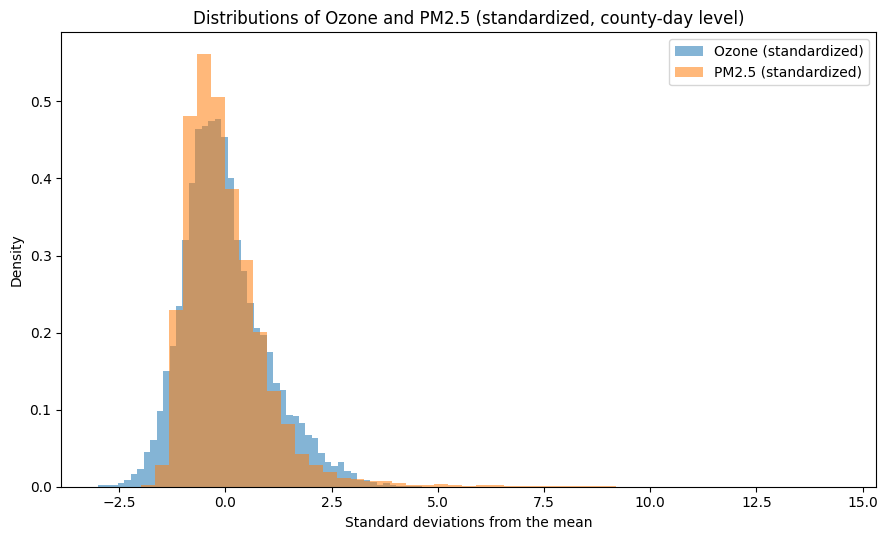

In [ ]:
# Ozone and PM2.5 are on very different scales (parts-per-million vs. micrograms
# per cubic meter), so plotting the raw values on one axis would just show PM2.5
# dwarfing ozone. Standardizing both to mean 0 / SD 1 preserves the *shape* of
# each distribution while putting them on a comparable scale.

ozone_std = (county_day["ozone_value"] - county_day["ozone_value"].mean()) / county_day["ozone_value"].std()
pm25_std = (county_day["pm25_value"] - county_day["pm25_value"].mean()) / county_day["pm25_value"].std()

plt.figure(figsize=(9, 5.5))
plt.hist(ozone_std.dropna(), bins=50, density=True, alpha=0.55, label="Ozone (standardized)")
plt.hist(pm25_std.dropna(), bins=50, density=True, alpha=0.55, label="PM2.5 (standardized)")
plt.xlabel("Standard deviations from the mean")
plt.ylabel("Density")
plt.title("Distributions of Ozone and PM2.5 (standardized, county-day level)")
plt.legend()
plt.tight_layout()
plt.show()

Standardizing rescales each variable but does not change its shape: skewness,
number of modes, and relative spread of the distribution are preserved, only the
units change (to "standard deviations from the mean"). Both ozone and PM2.5 turn
out to be right-skewed with a long right tail once put on this common scale,
which is easier to see side-by-side than it would be on the raw ppm/µg-per-m³ scales.

### 2.2 Ozone Time Series

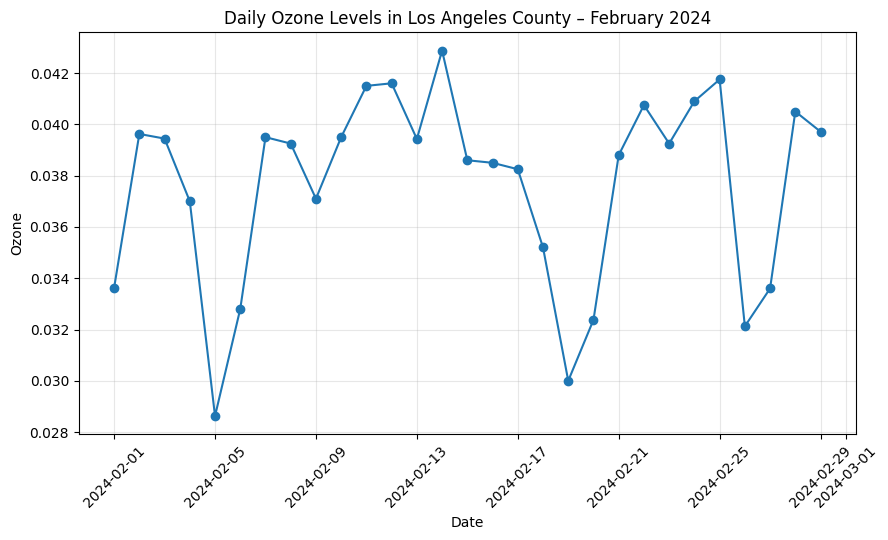

In [ ]:
county_day["date"] = pd.to_datetime(county_day["date"])

la_february = (
    county_day[
        (county_day["county_code"] == "037") &
        (county_day["date"].dt.month == 2)
    ]
    .sort_values("date")
)

plt.figure(figsize=(9, 5.5))
plt.plot(la_february["date"], la_february["ozone_value"], marker="o", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Ozone")
plt.title("Daily Ozone Levels in Los Angeles County \u2013 February 2024")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Yes, this looks autocorrelated: ozone doesn't jump around randomly from one day
to the next, it moves in multi-day runs \u2014 several days trending up followed by
several days trending down \u2014 which is exactly the pattern you'd expect if today's
value carries information about tomorrow's. A simple way to test this formally,
without doing it here, would be to plot the autocorrelation function (ACF) of
daily ozone and see whether the lag-1 (and higher-order) autocorrelations are
statistically different from zero, or equivalently to regress ozone on its own
lag(s) and test the lag coefficient(s).

## Section 3: Pollution and Mortality

### 3.1 Pollution and Mortality Regression

In [ ]:
base_model = smf.ols(
    "mortality ~ aqi + C(county_code) + C(date)",
    data=county_day
).fit()

print("\u03b21 (coefficient on AQI):", base_model.params["aqi"])

β1 (coefficient on AQI): 0.5277117046118772


/tmp/ipykernel_674/2492776155.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


A one-unit increase in AQI is associated with roughly a 0.53-unit increase in
daily county mortality, holding county and date fixed effects constant \u2014 i.e.
comparing days *within the same county* and comparing counties *on the same day*,
rather than pooling variation across fundamentally different places or times.

Fixed effects are included because county and day are both very likely correlated
with mortality for reasons that have nothing to do with pollution: counties differ
in population, age structure, healthcare access, and baseline environmental
conditions, and days differ because of things like flu season, heat waves, or
holidays that could move both pollution and mortality together. Without county
and date fixed effects, the AQI coefficient would partly be picking up these
confounding sources of variation instead of isolating the within-county,
within-day association between pollution and mortality.

*Note: `statsmodels` prints a rank-deficiency warning for this specification.
This is a consequence of Section 1.6 \u2014 several counties have far fewer than 366
observed days, and with an unbalanced panel like this some county/date fixed-effect
combinations become collinear with each other. It does not appear to affect the
AQI coefficient reported above (it's identified off the large majority of
counties/days that are fully observed), but it's worth flagging as a caveat on
the standard errors of the individual fixed-effect terms.*

### 3.2 Lagged Pollution Effects

In [ ]:
county_day = county_day.sort_values(["county_code", "date"])
county_day["aqi_lag1"] = county_day.groupby("county_code")["aqi"].shift(1)

lag_model = smf.ols(
    "mortality ~ aqi + aqi_lag1 + C(county_code) + C(date)",
    data=county_day
).fit()

print("Coefficient on current AQI:", lag_model.params["aqi"])
print("Coefficient on yesterday's AQI:", lag_model.params["aqi_lag1"])

Coefficient on current AQI: 0.3048106117412645
Coefficient on yesterday's AQI: 0.36869842951108833


/tmp/ipykernel_674/3079284706.py:7: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


Both coefficients are positive: holding the other one fixed (along with county
and date fixed effects), a one-unit increase in *today's* AQI is associated with
about a 0.30-unit increase in today's mortality, and a one-unit increase in
*yesterday's* AQI is associated with about a 0.37-unit increase in today's
mortality. The lagged effect is at least as large as the contemporaneous one,
which supports the concern that pollution's effect on mortality isn't limited to
the same day \u2014 a regression of mortality on AQI alone (as in 3.1) would have
been folding both of these into a single coefficient and missing this
same-day-vs-next-day distinction.

### 3.3 CBSA Interaction Effects

In [ ]:
# 1 = county belongs to a CBSA, 0 = it does not. Every observation for a given
# county has the same cbsacode (missing or not), so this is a county-level
# attribute, not something that varies day to day.
county_day["in_cbsa"] = county_day["cbsacode"].notna().astype(int)

# Only the interaction term is added on top of the Question 1 specification;
# a standalone in_cbsa term is intentionally left out (see 3.4).
interaction_model = smf.ols(
    "mortality ~ aqi + aqi:in_cbsa + C(county_code) + C(date)",
    data=county_day
).fit()

print("AQI coefficient:", interaction_model.params["aqi"])
print("AQI \u00d7 in-CBSA interaction coefficient:", interaction_model.params["aqi:in_cbsa"])

AQI coefficient: 0.5335947188771842
AQI × in-CBSA interaction coefficient: -0.006654964498224459


/tmp/ipykernel_674/1089098084.py:11: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


The interaction coefficient is essentially zero (about \u22120.007, an order of
magnitude smaller than the main AQI coefficient), which means the AQI-mortality
relationship for CBSA counties is barely distinguishable from the relationship
for non-CBSA counties \u2014 the association between pollution and mortality does not
meaningfully depend on whether a county belongs to a CBSA.

### 3.4 Collinearity & Fixed Effects

A standalone `in_cbsa` indicator was deliberately left out of the regression
above. The reason is that whether a county is in a CBSA is a fixed attribute of
the county \u2014 it doesn't change day to day \u2014 so `in_cbsa` is just a specific
linear combination of the county fixed-effect dummies (it equals 1 for the subset
of county dummies belonging to CBSA counties and 0 for the rest). Once
`C(county_code)` is already in the regression, adding a standalone `in_cbsa` term
supplies no new information: it's perfectly collinear with the county fixed
effects already in the model, so it could not be separately estimated. This is
exactly why the AQI\u00d7in_cbsa *interaction* is still identifiable even though the
*main effect* of in_cbsa is not: the interaction varies with AQI, which itself
varies within county over time, whereas a standalone in_cbsa term does not vary
within county at all.

## Section 4: Discussion on Threats

### 4.1 Lag length and omitted variable bias

If pollution follows an AR(3) process, then in principle three lags of pollution
are correlated with today's pollution, which is the "correlated with the variable
of interest" half of the omitted-variable-bias condition. But that's only half of
it: a lag only causes omitted variable bias if it is *also* independently related
to the outcome (mortality) once the other lags are already in the regression. If,
say, only lag 1 actually affects mortality while lags 2 and 3 are just
autocorrelated with pollution but don't independently move mortality, then
omitting lags 2 and 3 causes no bias in the lag-1 (or contemporaneous) coefficient
\u2014 there's nothing being "left out of the residual" that both belongs in the
outcome equation and is correlated with the included regressors. So the number of
lags needed for OVB purposes is not simply "however many lags are autocorrelated
with pollution" \u2014 it's however many lags would show up with a non-zero
coefficient if they were included directly in the mortality equation. Autocorrelation
in the regressor by itself is not sufficient for omitted variable bias.

### 4.2 Interpreting a null contemporaneous effect causally

Even a coefficient of zero on lagged pollution (so no apparent lag-related
confounding) would not be enough to give the Section 3.1 coefficient a causal
interpretation. Fixed effects for county and date only rule out confounders that
are constant within a county or constant within a day; they say nothing about
confounders that vary at the *county-day* level itself, which is exactly the same
level of variation the AQI coefficient is being identified from. Things like local
weather, wildfire smoke, or short-run economic activity can move both pollution
and mortality at the county-day level and would not be absorbed by either fixed
effect. There's also the harvesting/anticipation concern explored in 4.3, and the
possibility of behavioral responses (people staying indoors on high-AQI days,
which would bias the estimated effect toward zero rather than away from it).
Ruling out lagged confounding narrows down one specific threat but doesn't
address these others, so "causal" would still be too strong a claim.

### 4.3 Mortality harvesting

If pollution's main effect is harvesting \u2014 pulling forward deaths that would
have happened the next day anyway, rather than causing new deaths \u2014 then, with
the full set of controls needed to eliminate omitted variable bias:

- Regressing **tomorrow's** mortality on **today's** pollution should give a
  coefficient of roughly the same magnitude as the today-on-today coefficient,
  but with the **opposite sign**: a death "borrowed" from tomorrow by today's
  pollution is one fewer death that occurs on the day it would otherwise have
  occurred.
- Regressing the **sum** of today's and tomorrow's mortality on today's pollution
  should give a coefficient close to **zero**, because the extra deaths pulled
  into today are almost exactly offset by the missing deaths on tomorrow \u2014 the
  same underlying pool of people ends up dying over the two-day window regardless
  of pollution, pollution has just moved *when* within that window it happens
  rather than *whether* it happens.

In short, a purely harvesting-driven pollution effect would look real in a
same-day regression, would show up as a mirror-image negative effect one day
later, and would wash out almost entirely once the two days are combined \u2014 which
is a useful diagnostic for distinguishing harvesting from a genuine increase in
total mortality.